In [1]:
import functools as ft
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
from scipy.signal import correlate, find_peaks

from utils.plots import *
from utils.quat import quat_to_euler

h5_dir = os.path.join('data','real', 'new', 'rosbags')
# bag_name = 'rosbag2_2025_05_19-18_58_24-run4-setpoints'
# bag_name = 'rosbag2_2025_05_19-19_03_24-run5'
# bag_name = 'rosbag2_2025_05_19-19_10_43-run6'
# bag_name = 'rosbag2_2025_09_25-16_37_13-figure8-erpm-mellinger'
# bag_name = 'rosbag2_2025_09_26-12_43_08-melon-20s-30-pid-run1'

# bag_name = 'rosbag2_2025_09_26-17_47_46-random-2-pid-run3-maxtilt40'
# bag_name = 'rosbag2_2025_09_26-17_49_23-melon-7-pid-run1-maxtilt40'
# bag_name = 'rosbag2_2025_09_26-18_24_03-melon-1809-pid-run1-maxtilt40-mocap'
# bag_name = 'rosbag2_2025_09_26-18_56_12-random-1848-pid-run1-maxtilt35-mocap'
# bag_name = 'rosbag2_2025_09_25-16_28_39-figure8-erpm-pid'
# bag_name = 'rosbag2_2025_09_25-16_37_13-figure8-erpm-mellinger'
# bag_name = 'rosbag2_2025_10_17-12_01_33-figure8-pid-mocap-run1'
# bag_name = 'rosbag2_2025_10_17-14_09_30-figure8-mellinger-mocap-run2'
bag_name = 'rosbag2_2025_10_17-15_06_44-square_20251017_145358-mellinger-mocap-run2'
# bag_name = 'rosbag2_2025_10_17-18_27_13-multisine_20251017_181408-mellinger-mocap-run4-dark'

h5_path = os.path.join(h5_dir, f'{bag_name}.h5')

# Load HDF5 bag files

In [2]:
dfs = dict()

with pd.HDFStore(h5_path, 'r') as store:
    for key in store.keys():
        df = pd.read_hdf(h5_path, key=key)
        dfs[key] = df


*** /clicked_point ***
Number of samples: 0

*** /goal_pose ***
Number of samples: 0

*** /initialpose ***
Number of samples: 0

*** /joy ***
Number of samples: 1160
Sample rate: mean 20.1Hz, median 19.9Hz
Columns:
 - header.stamp.sec
 - header.stamp.nanosec
 - header.frame_id
 - axes.0
 - axes.1
 - axes.2
 - axes.3
 - buttons.0
 - buttons.1
 - buttons.2
 - buttons.3
 - buttons.4
 - buttons.5
 - buttons.6
 - buttons.7
 - buttons.8
 - buttons.9
 - buttons.10
 - buttons.11
 - buttons.12
 - buttons.13
 - buttons.14
 - buttons.15
 - timestamp

*** /poses ***
Number of samples: 5135
Sample rate: mean 126.8Hz, median 99.7Hz
Columns:
 - header.stamp.sec
 - header.stamp.nanosec
 - header.frame_id
 - poses.0.name
 - poses.0.pose.position.x
 - poses.0.pose.position.y
 - poses.0.pose.position.z
 - poses.0.pose.orientation.x
 - poses.0.pose.orientation.y
 - poses.0.pose.orientation.z
 - poses.0.pose.orientation.w
 - timestamp

*** /rosout ***
Number of samples: 2030
Sample rate: mean 14059.2Hz, m

C:\Users\riccardo.busetto\Documents\GitHub\nanodrone-sysid-mpc\.venv\Lib\site-packages\numpy\lib\nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


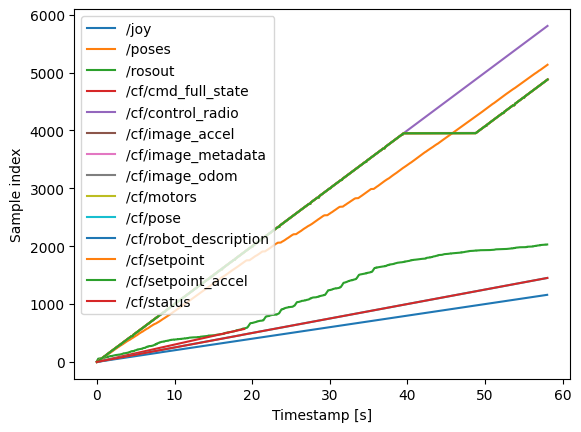

In [3]:
plt.figure()

for key, df in dfs.items():
    print()
    print(f'*** {key} ***')

    n_samples = len(df)
    print(f'Number of samples: {n_samples}')
        
    if n_samples == 0:
        continue

    timestamp_s = df.timestamp / 1e9
    timestamp_s -= timestamp_s.iloc[0]
    
    sample_rate = 1 / timestamp_s.diff()
    print(f'Sample rate: mean {sample_rate.mean():.1f}Hz, median {sample_rate.median():.1f}Hz')

    print('Columns:')
    for column in df.columns:
        print(f' - {column}')
    

    plt.plot(timestamp_s, df.index, label=key)
    plt.xlabel('Timestamp [s]')
    plt.ylabel('Sample index')

plt.legend();

# Extract data from individual topics

In [4]:
def extract_cols(df, cols, prefix=[]):
    if isinstance(cols, list):
        cols = dict(zip(cols, cols))
        
    cols = {
        '.'.join(prefix + [old]): new for old, new in cols.items()
    }
    
    return df[cols.keys()].rename(columns=cols)

def extract_position(df, prefix=[]):
    return extract_cols(df, ['x', 'y', 'z'], prefix)

def extract_orientation(df, prefix=[]):
    df = extract_cols(df, {'x': 'qx', 'y': 'qy', 'z': 'qz', 'w': 'qw'}, prefix)

    quats = df.values # shape (T, 4)
    euler_angles = jax.vmap(quat_to_euler)(quats)  # shape (T, 3)
    yaw, pitch, roll = euler_angles.T
    df['yaw'] = np.asarray(yaw)
    df['pitch'] = np.asarray(pitch)
    df['roll'] = np.asarray(roll)
    
    return df

def extract_pose(df, prefix=[]):
    return pd.concat([
        extract_position(df, prefix=prefix + ['position']),
        extract_orientation(df, prefix=prefix + ['orientation']),
    ], axis=1)
    
def extract_lin_vel(df, prefix=[]):
    return extract_cols(df, {'x': 'vx', 'y': 'vy', 'z': 'vz'}, prefix)

def extract_ang_vel(df, prefix=[]):
    return extract_cols(df, {'x': 'wx', 'y': 'wy', 'z': 'wz'}, prefix)

def extract_twist(df, prefix=[]):
    return pd.concat([
        extract_lin_vel(df, prefix=prefix + ['linear']),
        extract_ang_vel(df, prefix=prefix + ['angular']),
    ], axis=1)

def extract_odom(df, prefix=[]):
    return pd.concat([
        extract_pose(df, prefix=prefix + ['pose.pose']),
        extract_twist(df, prefix=prefix + ['twist.twist']),
    ], axis=1)

def extract_lin_accel(df, prefix=[]):
    return extract_cols(df, {'x': 'ax', 'y': 'ay', 'z': 'az'}, prefix)

def extract_motors_radio(df, prefix=[]):
    df = extract_cols(df, {'0': 'm1', '1': 'm2', '2': 'm3', '3': 'm4'}, prefix)
    df /= (2**16 - 1)
    return df

def extract_motor_thrusts(df, prefix=[]):
    df = extract_cols(df, {'m1': 'm1_thrust', 'm2': 'm2_thrust', 'm3': 'm3_thrust', 'm4': 'm4_thrust'}, prefix)
    df /= (2**16 - 1)
    return df

def extract_motor_erpm(df, prefix=[]):
    df = extract_cols(df, {'m1': 'm1_erpm', 'm2': 'm2_erpm', 'm3': 'm3_erpm', 'm4': 'm4_erpm'}, prefix)
    df = df.replace(65535, np.nan)
    df *= 100
    return df

def extract_motors(df, prefix=[]):
    return pd.concat([
        extract_motor_thrusts(df, prefix=prefix + ['thrust']),
        extract_motor_erpm(df, prefix=prefix + ['erpm']),
    ], axis=1)

def extract_controls(df, prefix=[]):
    df = extract_cols(df, {'0': 'thrust', '1': 'torque_roll', '2': 'torque_pitch', '3': 'torch_yaw'}, prefix)
    df /= (2**16 - 1)
    return df

def extract_supervisor_info(df, prefix=[]):
    df = extract_cols(df, ['supervisor_info'], prefix)
    df = pd.DataFrame({
        'can_be_armed': df.supervisor_info & (1 << 0),
        'is_armed': df.supervisor_info & (1 << 1),
        'auto_arm': df.supervisor_info & (1 << 2),
        'can_fly': df.supervisor_info & (1 << 3),
        'is_flying': df.supervisor_info & (1 << 4),
        'is_tumbled': df.supervisor_info & (1 << 5),
        'is_locked': df.supervisor_info & (1 << 6),
    }).astype(bool)
    return df

def extract_status(df, prefix=[]):
    return pd.concat([
        extract_cols(df, {'battery_voltage': 'Vbat'}, prefix),
        extract_supervisor_info(df, prefix)
    ], axis=1)

def extract_metadata(df, prefix=[]):
    return extract_cols(df, ['setpoint_priority', 'state_stm32_timestamp', 'setpoint_stm32_timestamp'], prefix)

topic_map = {
    '/poses': ft.partial(extract_pose, prefix=['poses.0.pose']),
    
    '/cf/status': extract_status,
    '/cf/pose': ft.partial(extract_pose, prefix=['pose']),
    '/cf/control_radio': ft.partial(extract_controls, prefix=['values']),
    
    '/cf/image_metadata': extract_metadata,
    '/cf/image_odom': extract_odom,
    '/cf/image_accel': ft.partial(extract_lin_accel, prefix=['accel.accel.linear']),
    '/cf/setpoint': extract_odom,
    '/cf/motors': ft.partial(extract_motors),
}

In [5]:
dfs.keys()

dict_keys(['/clicked_point', '/goal_pose', '/initialpose', '/joy', '/poses', '/rosout', '/events/write_split', '/cf/cmd_full_state', '/cf/cmd_position', '/cf/cmd_vel_legacy', '/cf/control_radio', '/cf/cpx', '/cf/image_accel', '/cf/image_metadata', '/cf/image_odom', '/cf/inference_onboard', '/cf/motors', '/cf/pose', '/cf/robot_description', '/cf/setpoint', '/cf/setpoint_accel', '/cf/status', '/cf/tof_raw', '/all/cmd_full_state'])

In [6]:
extract_dfs = {}
for topic, extract_fn in topic_map.items():
    msg_df = dfs[topic]

    # ROS timestamp, message received by ros2 bag record
    timestamp = msg_df.timestamp / 1e9
    
    # ROS timestamp, message published by its publisher (prefer if available)
    if 'header.stamp.sec' in msg_df:
        timestamp = msg_df['header.stamp.sec'] + msg_df['header.stamp.nanosec'] / 1e9

    df = extract_fn(msg_df)

    df['t'] = timestamp - timestamp.iloc[0]
    
    extract_dfs[topic] = df
    
    print(topic)
    print(df)

/poses
             x         y         z  qx  qy  qz  qw  yaw  pitch  roll  \
0     0.004197  0.036701  0.052216 NaN NaN NaN NaN  NaN    NaN   NaN   
1     0.004200  0.036671  0.052213 NaN NaN NaN NaN  NaN    NaN   NaN   
2     0.004213  0.036716  0.052220 NaN NaN NaN NaN  NaN    NaN   NaN   
3     0.004157  0.036701  0.052234 NaN NaN NaN NaN  NaN    NaN   NaN   
4     0.004187  0.036665  0.052198 NaN NaN NaN NaN  NaN    NaN   NaN   
...        ...       ...       ...  ..  ..  ..  ..  ...    ...   ...   
5130 -0.010858  0.002369  0.052414 NaN NaN NaN NaN  NaN    NaN   NaN   
5131 -0.010837  0.002374  0.052417 NaN NaN NaN NaN  NaN    NaN   NaN   
5132 -0.010871  0.002370  0.052432 NaN NaN NaN NaN  NaN    NaN   NaN   
5133 -0.010844  0.002380  0.052438 NaN NaN NaN NaN  NaN    NaN   NaN   
5134 -0.010847  0.002381  0.052436 NaN NaN NaN NaN  NaN    NaN   NaN   

              t  
0      0.000000  
1      0.016550  
2      0.025892  
3      0.046169  
4      0.055994  
...         ...  
51

<Axes: >

<Figure size 640x480 with 0 Axes>

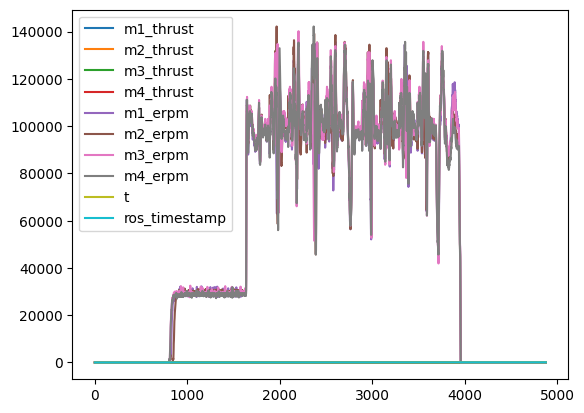

In [18]:
plt.figure()
(extract_dfs['/cf/motors']).plot()

# Time synchronization

In [8]:
# Topics streamed from the drone over Wi-Fi
# Latency is unpredictable, so ROS timestamps are unreliable for these topics. 
# Extract the hardware timestamp from image_metadata and use it to retime the messages.
wifi_topics = {
    '/cf/image_odom': 'state_stm32_timestamp',
    '/cf/image_accel': 'state_stm32_timestamp',
    '/cf/motors': 'state_stm32_timestamp',
    '/cf/setpoint': 'setpoint_stm32_timestamp',
}
metadata_topic = '/cf/image_metadata'

for topic, timestamp_field in wifi_topics.items():
    data_df = extract_dfs[topic].copy()
    metadata_df = extract_dfs[metadata_topic]

    metadata_df = metadata_df[metadata_df[timestamp_field] != 0]
    
    # merge_df = pd.merge(data_df, metadata_df, on='t', how='left')
    merge_df = pd.merge_asof(data_df, metadata_df, on='t', direction='nearest')
    
    hw_timestamp = merge_df[timestamp_field] / 1e3

    data_df['ros_timestamp'] = data_df.t
    data_df['t'] = hw_timestamp

    data_df = data_df.drop_duplicates('t')

    extract_dfs[topic] = data_df

In [9]:
extract_dfs.keys()

dict_keys(['/poses', '/cf/status', '/cf/pose', '/cf/control_radio', '/cf/image_metadata', '/cf/image_odom', '/cf/image_accel', '/cf/setpoint', '/cf/motors'])

<Axes: xlabel='t'>

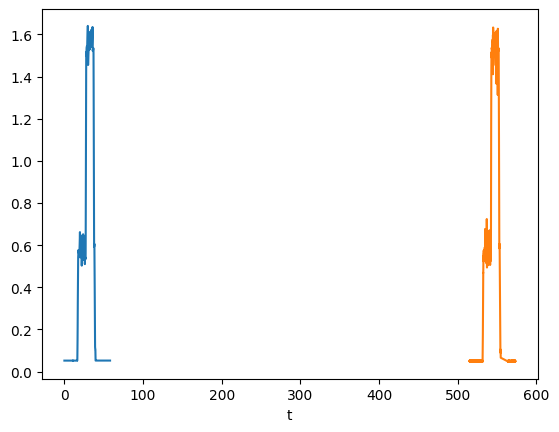

In [10]:
plt.figure()
extract_dfs['/poses'].set_index('t').z.plot()
extract_dfs['/cf/image_odom'].set_index('t').z.plot()

In [11]:
# Estimate latencies from a reference signal
# Use mocap as time base reference as it should always be available even if drones are rebooted
latency_ref_base = '/poses'

# Estimate a clock delay for each group of topics, based on the communication interface
topic_sources = {
    '/poses': 'mocap',
    
    '/cf/pose': 'radio',
    # '/cf/motors_radio': 'radio',
    '/cf/status': 'radio',
    '/cf/control_radio': 'radio',
    
    '/cf/image_metadata': 'wifi',
    '/cf/image_odom': 'wifi',
    '/cf/image_accel': 'wifi',
    '/cf/motors': 'wifi',
    '/cf/setpoint': 'wifi',
}

# Use drone altitude as reference signal as it has absolute measurements from both the mocap and drone
latency_ref_field = 'z'
latency_ref_topic = {
    'mocap': '/poses',
    'radio': '/cf/pose',
    'wifi': '/cf/image_odom',
}

# fig, axs = plt.subplots(len(latency_ref_topic), 1)
#
# clock_delays = {}
# for ax, (source, topic) in zip(axs, latency_ref_topic.items()):
#     ref_signal = extract_dfs[latency_ref_base].set_index('t')[latency_ref_field]
#
#     meas_signal = extract_dfs[topic].set_index('t')[latency_ref_field]
#
#     meas_signal = meas_signal.copy()
#     start_timestamp = meas_signal.index[0]
#     meas_signal.index -= start_timestamp
#
#     # meas_signal = meas_signal[~meas_signal.index.duplicated()]
#     meas_signal = meas_signal.reindex(ref_signal.index, method='nearest')
#
#     ref_clock = ref_signal.index
#     meas_clock = meas_signal.index
#
#     # Normalize
#     ref_signal = (ref_signal - np.mean(ref_signal)) / np.std(ref_signal)
#     meas_signal = (meas_signal - np.mean(meas_signal)) / np.std(meas_signal)
#
#     # Cross-correlation
#     corr = correlate(meas_signal, ref_signal, mode='same')
#
#     # Find global maximum
#     peak = np.argmax(corr)
#
#     delay_samples = peak - len(ref_signal) // 2
#     clock_delays[source] = np.nanmedian(ref_clock.diff()) * delay_samples - start_timestamp
#
#     ax.set_title(f'{source}')
#     ax.plot(ref_signal.index, ref_signal.values, label='Reference signal')
#     ax.plot(meas_signal.index, meas_signal.values, label='Meas. signal')
#     ax.plot(meas_signal.index - clock_delays[source], meas_signal.values, label='Aligned signal')
#     ax2 = ax.twinx()
#     ax2.plot(ref_signal.index, corr, 'r')
#     ax2.plot(ref_signal.index[peak], corr[peak], 'rx')
#     ax.legend()
#
# fig.tight_layout()
#
# print(clock_delays)


Estimated clock delays (seconds):
  mocap   : +0.000 s
  radio   : +0.000 s
  wifi    : +515.060 s


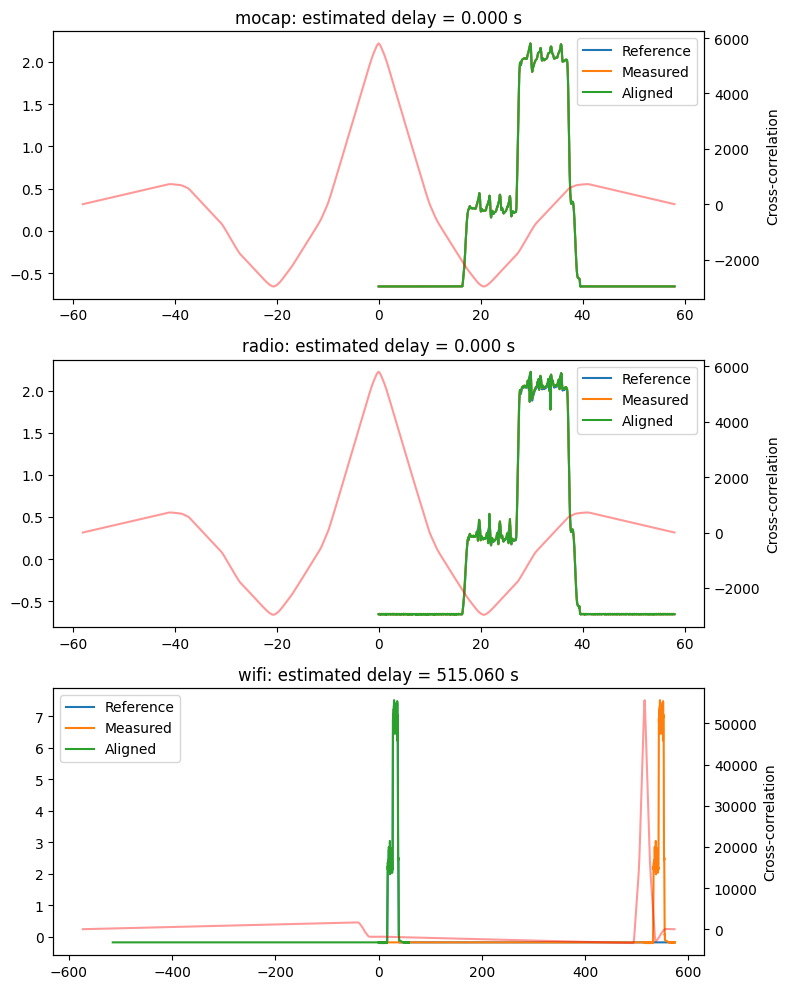

In [12]:
from scipy.signal import correlate
import numpy as np
import matplotlib.pyplot as plt

clock_delays = {}
fs = 100.0  # resampling frequency

fig, axs = plt.subplots(len(latency_ref_topic), 1, figsize=(8, 10))

for ax, (source, topic) in zip(axs, latency_ref_topic.items()):
    ref_signal = extract_dfs[latency_ref_base].set_index('t')[latency_ref_field]
    meas_signal = extract_dfs[topic].set_index('t')[latency_ref_field]

    # Define the full time span (union, not overlap)
    t_min = min(ref_signal.index[0], meas_signal.index[0])
    t_max = max(ref_signal.index[-1], meas_signal.index[-1])
    t_uniform = np.arange(t_min, t_max, 1/fs)

    # Interpolate with extrapolation (so no NaNs at ends)
    ref_interp = np.interp(t_uniform, ref_signal.index, ref_signal.values,
                           left=ref_signal.values[0], right=ref_signal.values[-1])
    meas_interp = np.interp(t_uniform, meas_signal.index, meas_signal.values,
                            left=meas_signal.values[0], right=meas_signal.values[-1])

    # Normalize
    ref_norm = (ref_interp - np.mean(ref_interp)) / np.std(ref_interp)
    meas_norm = (meas_interp - np.mean(meas_interp)) / np.std(meas_interp)

    # Cross-correlation to find delay
    corr = correlate(meas_norm, ref_norm, mode='full')
    lags = np.arange(-len(ref_norm) + 1, len(meas_norm))
    peak = np.argmax(corr)
    delay_samples = lags[peak]
    delay_seconds = delay_samples / fs
    clock_delays[source] = delay_seconds

    # Plot
    ax.plot(t_uniform, ref_norm, label='Reference')
    ax.plot(t_uniform, meas_norm, label='Measured')
    ax.plot(t_uniform - delay_seconds, meas_norm, label='Aligned')
    ax.legend()
    ax.set_title(f'{source}: estimated delay = {delay_seconds:.3f} s')

    ax2 = ax.twinx()
    ax2.plot(lags / fs, corr, 'r', alpha=0.4)
    ax2.set_ylabel('Cross-correlation')

fig.tight_layout()
print("\nEstimated clock delays (seconds):")
for src, delay in clock_delays.items():
    print(f"  {src:<8}: {delay:+.3f} s")


In [13]:
# FIXME: manually compensate delay computed from correlation for run6
#clock_delays['wifi'] += 0.7

# Re-time all topics based on the respective clocks
for topic, source in topic_sources.items():
    clock_delay = clock_delays[source]
    extract_dfs[topic]['t'] -= clock_delay

# Visualization

![Drone diagram](data/images/drone.png)

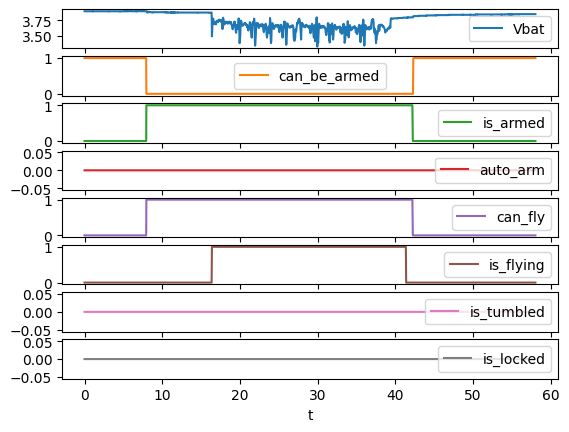

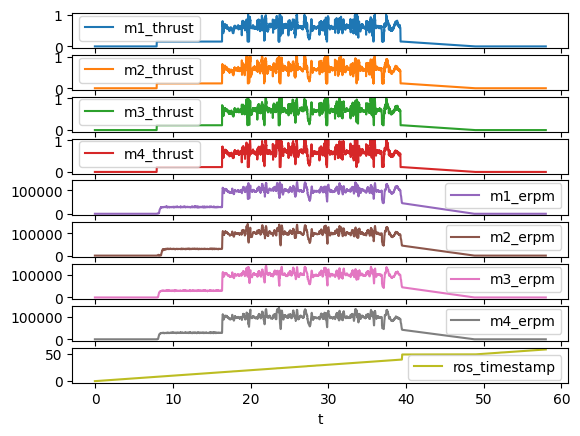

In [14]:
extract_dfs['/cf/status'].set_index('t').plot(subplots=True, include_bool=True)
extract_dfs['/cf/motors'].set_index('t').plot(subplots=True);

# Final

Here I compare the recorded data from the different data sources:
- State estimation streamed over Wi-Fi - all components (pos, vel, orient, ang. vel) but has occasional packet drops
- State estimation streamed over radio - pos only, but more reliable
- Motion capture - pos only

- Setpoints streamed over Wi-Fi - pos and vel only, the rest are controlled reactively by the onboard PIDs

In [15]:
extract_dfs['/cf/control_radio']

,thrust,torque_roll,torque_pitch,torch_yaw,t
0,0.0,0.0,0.0,0.0,0.000000
1,0.0,0.0,0.0,0.0,0.010017
2,0.0,0.0,0.0,0.0,0.019824
3,0.0,0.0,0.0,0.0,0.028977
4,0.0,0.0,0.0,0.0,0.039875
...,...,...,...,...,...
5801,0.0,0.0,0.0,0.0,57.997175
5802,0.0,0.0,0.0,0.0,58.013202
5803,0.0,0.0,0.0,0.0,58.018213
5804,0.0,0.0,0.0,0.0,58.027190


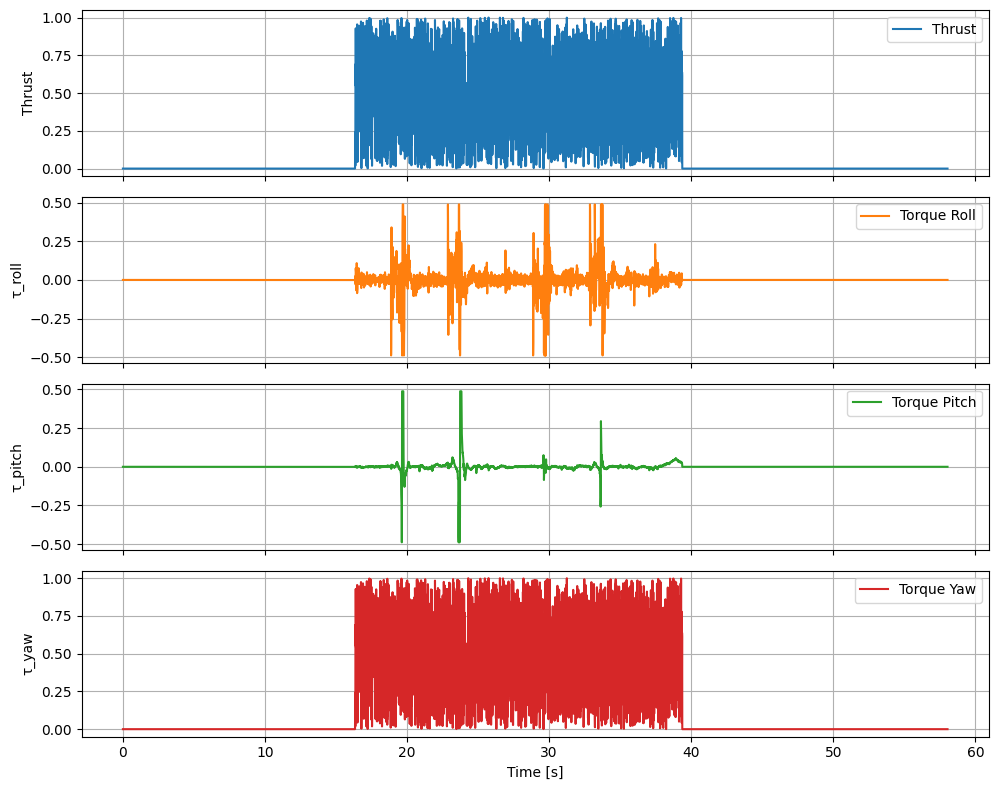

In [16]:
t = extract_dfs['/cf/control_radio']['t']
thrust = extract_dfs['/cf/control_radio']['thrust']
tau_roll = extract_dfs['/cf/control_radio']['torque_roll']
tau_pitch = extract_dfs['/cf/control_radio']['torque_pitch']
tau_yaw = extract_dfs['/cf/control_radio']['torch_yaw']

fig, axs = plt.subplots(4, 1, figsize=(10, 8), sharex=True)

axs[0].plot(t, thrust, label="Thrust")
axs[0].set_ylabel("Thrust")
axs[0].grid(True)
axs[0].legend()

axs[1].plot(t, tau_roll, label="Torque Roll", color="C1")
axs[1].set_ylabel("τ_roll")
axs[1].grid(True)
axs[1].legend()

axs[2].plot(t, tau_pitch, label="Torque Pitch", color="C2")
axs[2].set_ylabel("τ_pitch")
axs[2].grid(True)
axs[2].legend()

axs[3].plot(t, tau_yaw, label="Torque Yaw", color="C3")
axs[3].set_ylabel("τ_yaw")
axs[3].set_xlabel("Time [s]")
axs[3].grid(True)
axs[3].legend()

plt.tight_layout()
plt.show()

In [660]:
state_wifi_df = extract_dfs['/cf/image_odom']
state_radio_df = extract_dfs['/cf/pose']
mocap_df = extract_dfs['/poses']
setpoint_df = extract_dfs['/cf/setpoint']

In [661]:
extract_dfs.keys()

dict_keys(['/poses', '/cf/status', '/cf/pose', '/cf/control_radio', '/cf/image_metadata', '/cf/image_odom', '/cf/image_accel', '/cf/setpoint', '/cf/motors'])

In [662]:
extract_dfs['/poses']

,x,y,z,qx,qy,qz,qw,yaw,pitch,roll,t
0,0.032065,0.007386,0.051821,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
1,0.032132,0.007428,0.051820,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.009981
2,0.032056,0.007429,0.051821,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.019717
3,0.032143,0.007225,0.051719,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.029727
4,0.032110,0.007405,0.051755,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.039798
...,...,...,...,...,...,...,...,...,...,...,...
7192,-1.169409,-1.472578,0.047471,NaN,NaN,NaN,NaN,NaN,NaN,NaN,73.021275
7193,-1.169469,-1.472565,0.047481,NaN,NaN,NaN,NaN,NaN,NaN,NaN,73.031374
7194,-1.169461,-1.472557,0.047463,NaN,NaN,NaN,NaN,NaN,NaN,NaN,73.041309
7195,-1.169475,-1.472568,0.047484,NaN,NaN,NaN,NaN,NaN,NaN,NaN,73.051596


<Axes: xlabel='t', ylabel='z'>

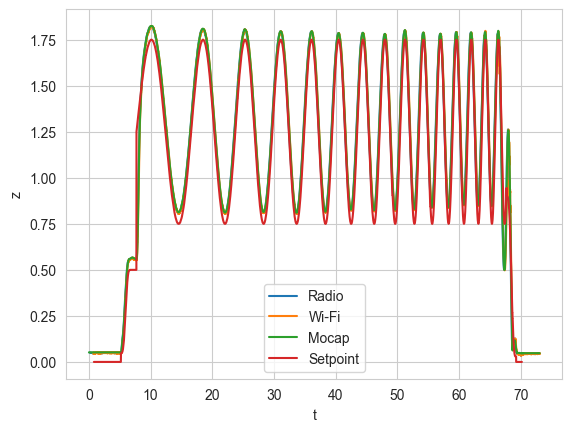

In [663]:
plt.figure()
sns.lineplot(state_radio_df, x='t', y='z', label="Radio")
sns.lineplot(state_wifi_df, x='t', y='z', label="Wi-Fi")
sns.lineplot(mocap_df, x='t', y='z', label="Mocap")
sns.lineplot(setpoint_df, x='t', y='z', label="Setpoint")

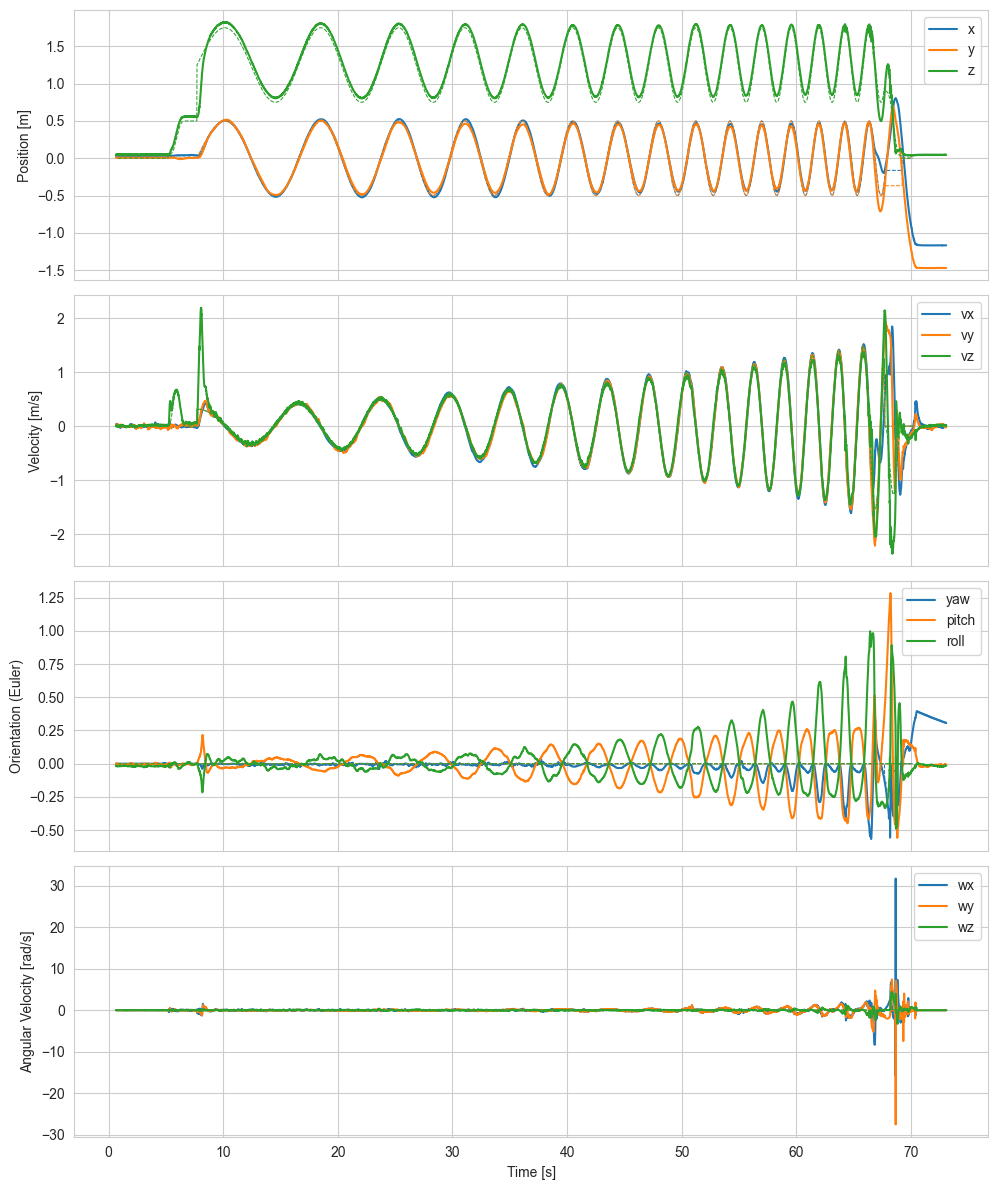

In [664]:
plot_state_grid(state_wifi_df, setpoint_df, orient='euler');

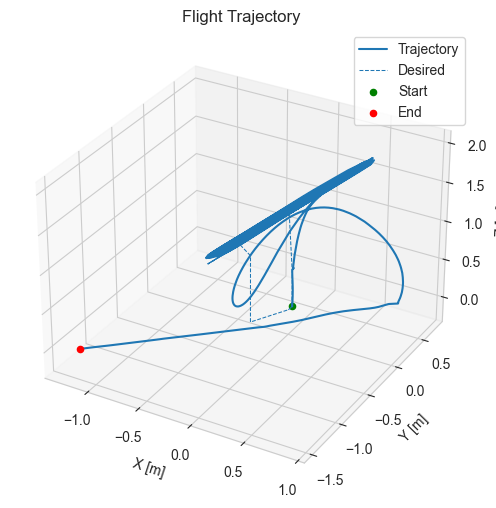

In [665]:
plot_3d_trajectory(mocap_df, setpoint_df, step=-1);

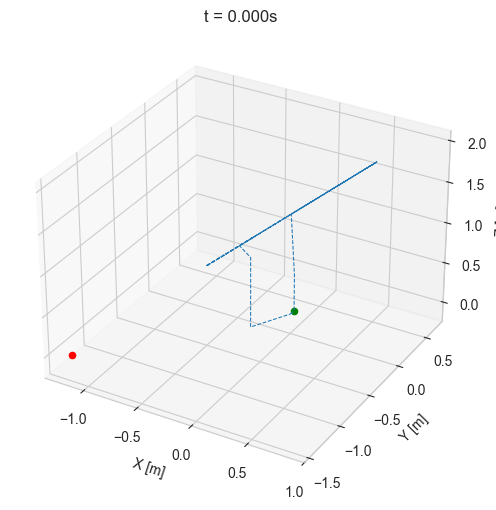

In [666]:
anim = animate_trajectory(mocap_df, setpoint_df, subsample=10);

In [667]:
plt.close('all')

In [668]:
# Get flying timestamps
# flying_mask = extract_dfs['/cf/motors']['m1_thrust'] >= 0.15
# flying_times = extract_dfs['/cf/motors'].loc[flying_mask, 't']
flying_mask = extract_dfs['/cf/status']['is_flying'] == True
flying_times = extract_dfs['/cf/status'].loc[flying_mask, 't']
t_min, t_max = flying_times.min(), flying_times.max()

# Dynamically filter all DataFrames based on the t range
for key in ['/poses', '/cf/motors', '/cf/image_odom', '/cf/image_accel', '/cf/setpoint', '/cf/status']:
    if 't' in df.columns:
        df = extract_dfs[key]
        extract_dfs[key] = df[(df['t'] >= t_min) & (df['t'] <= t_max)]
        print(f"{key}: {extract_dfs[key].shape}")

# Step 3: Normalize time so that first /cf/image_odom time is zero
# for key in ['/cf/motors', '/cf/image_odom', '/cf/image_accel', '/cf/setpoint', '/cf/status']:
#     t0 = extract_dfs[key]['t'].min()
#     extract_dfs[key]['t'] -= t0

# Step 4: Sort all DataFrames by 't' (required for merge_asof)
for key in ['/poses', '/cf/motors', '/cf/image_odom', '/cf/image_accel', '/cf/setpoint', '/cf/status']:
    extract_dfs[key] = extract_dfs[key].sort_values('t')

# Step 5: Merge all dataframes using 't' from /cf/image_odom as reference
merged_df = extract_dfs['/cf/image_odom'].copy()

# Rename all columns of /poses except 't' to add '_mocap' suffix
poses_df = extract_dfs['/poses'].copy()
poses_df = poses_df.rename(
    columns={col: f"{col}_mocap" for col in poses_df.columns if col != 't'}
)

# Merge step-by-step using nearest time match (direction='nearest' is also an option)
merged_df = pd.merge_asof(merged_df,poses_df, on='t', direction='nearest') # mocap
merged_df = pd.merge_asof(merged_df, extract_dfs['/cf/motors'], on='t', direction='nearest') # erpm
merged_df = pd.merge_asof(merged_df, extract_dfs['/cf/control_radio'], on='t', direction='nearest') # control thrust, torques
merged_df = pd.merge_asof(merged_df, extract_dfs['/cf/image_accel'], on='t', direction='nearest') # ax, ay, az
merged_df = pd.merge_asof(merged_df, extract_dfs['/cf/setpoint'], on='t', suffixes=('', '_r'), direction='nearest') # setpoins
merged_df = pd.merge_asof(merged_df, extract_dfs['/cf/status'], on='t', direction='nearest') # status

merged_df['t'] = merged_df['t'] - merged_df['t'][0]
merged_df['wy'] = -merged_df['wy']
# Now merged_df has all aligned data
print("Merged dataframe shape:", merged_df.shape)

/poses: (6381, 11)
/cf/motors: (5828, 10)
/cf/image_odom: (6351, 18)
/cf/image_accel: (5828, 5)
/cf/setpoint: (2228, 18)
/cf/status: (1624, 9)
Merged dataframe shape: (6351, 70)


In [669]:
print(merged_df.shape)
merged_df = merged_df.drop_duplicates(subset='t', keep='first')
print(merged_df.shape)

(6351, 70)
(6351, 70)


In [670]:
t_min = merged_df['t'].min()
t_max = merged_df['t'].max()

# Generate uniformly spaced time vector at 100 Hz (i.e. every 0.01s)
t_uniform = np.arange(t_min, t_max, 0.01)

resampled_df = merged_df.set_index('t').reindex(t_uniform, method="nearest").reset_index()
resampled_df.rename(columns={'index': 't'}, inplace=True)

In [671]:
resampled_df.columns

Index(['t', 'x', 'y', 'z', 'qx', 'qy', 'qz', 'qw', 'yaw', 'pitch', 'roll',
       'vx', 'vy', 'vz', 'wx', 'wy', 'wz', 'ros_timestamp_x', 'x_mocap',
       'y_mocap', 'z_mocap', 'qx_mocap', 'qy_mocap', 'qz_mocap', 'qw_mocap',
       'yaw_mocap', 'pitch_mocap', 'roll_mocap', 'm1_thrust', 'm2_thrust',
       'm3_thrust', 'm4_thrust', 'm1_erpm', 'm2_erpm', 'm3_erpm', 'm4_erpm',
       'ros_timestamp_y', 'thrust', 'torque_roll', 'torque_pitch', 'torch_yaw',
       'ax', 'ay', 'az', 'ros_timestamp', 'x_r', 'y_r', 'z_r', 'qx_r', 'qy_r',
       'qz_r', 'qw_r', 'yaw_r', 'pitch_r', 'roll_r', 'vx_r', 'vy_r', 'vz_r',
       'wx_r', 'wy_r', 'wz_r', 'ros_timestamp_r', 'Vbat', 'can_be_armed',
       'is_armed', 'auto_arm', 'can_fly', 'is_flying', 'is_tumbled',
       'is_locked'],
      dtype='object')

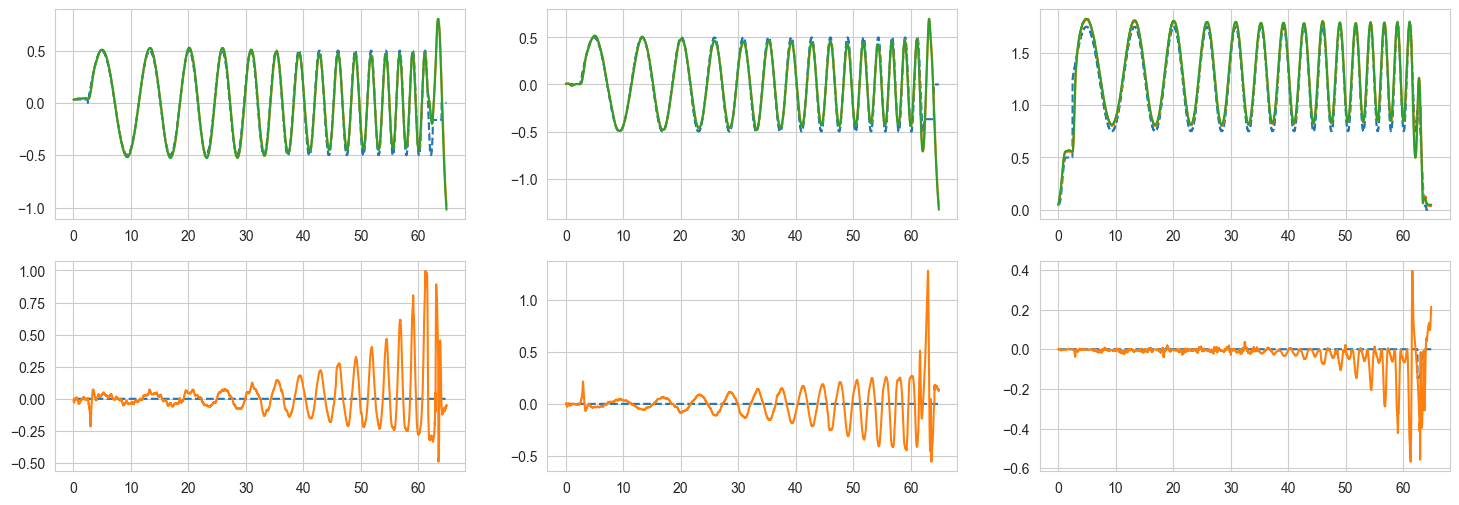

In [672]:
plt.subplots(2,3, figsize = (18,6))

plt.subplot(231)
plt.plot(resampled_df['t'], resampled_df['x_r'], '--')
plt.plot(resampled_df['t'], resampled_df['x'])
plt.plot(resampled_df['t'], resampled_df['x_mocap'])

plt.subplot(232)
plt.plot(resampled_df['t'], resampled_df['y_r'], '--')
plt.plot(resampled_df['t'], resampled_df['y'])
plt.plot(resampled_df['t'], resampled_df['y_mocap'])

plt.subplot(233)
plt.plot(resampled_df['t'], resampled_df['z_r'], '--')
plt.plot(resampled_df['t'], resampled_df['z'])
plt.plot(resampled_df['t'], resampled_df['z_mocap'])

plt.subplot(234)
plt.plot(resampled_df['t'], resampled_df['roll_r'], '--')
plt.plot(resampled_df['t'], resampled_df['roll'])
plt.plot(resampled_df['t'], resampled_df['roll_mocap'])

plt.subplot(235)
plt.plot(resampled_df['t'], resampled_df['pitch_r'], '--')
plt.plot(resampled_df['t'], resampled_df['pitch'])
plt.plot(resampled_df['t'], resampled_df['pitch_mocap'])

plt.subplot(236)
plt.plot(resampled_df['t'], resampled_df['yaw_r'], '--')
plt.plot(resampled_df['t'], resampled_df['yaw'])
plt.plot(resampled_df['t'], resampled_df['yaw_mocap'])

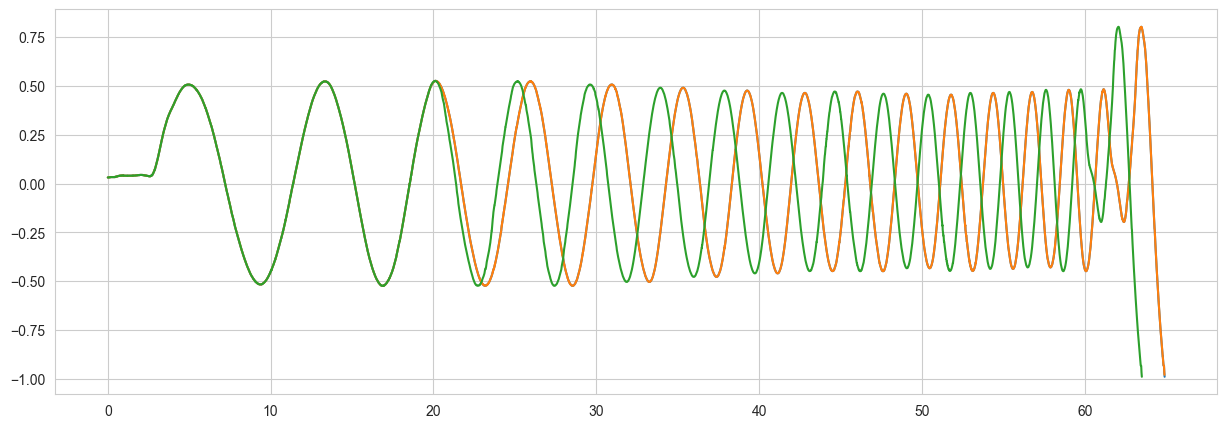

In [673]:
plt.figure(figsize=(15,5))
plt.plot(merged_df['t'], merged_df['x'])
plt.plot(resampled_df['t'], resampled_df['x'])
plt.plot(np.arange(merged_df.shape[0])*0.01, merged_df['x'])

In [674]:
resampled_df.to_parquet(os.path.join('../control_engineering_practice/data/real/new/parquets', bag_name + '.parquet'))

C:\Users\riccardo.busetto\AppData\Local\Temp\ipykernel_26916\2935169399.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


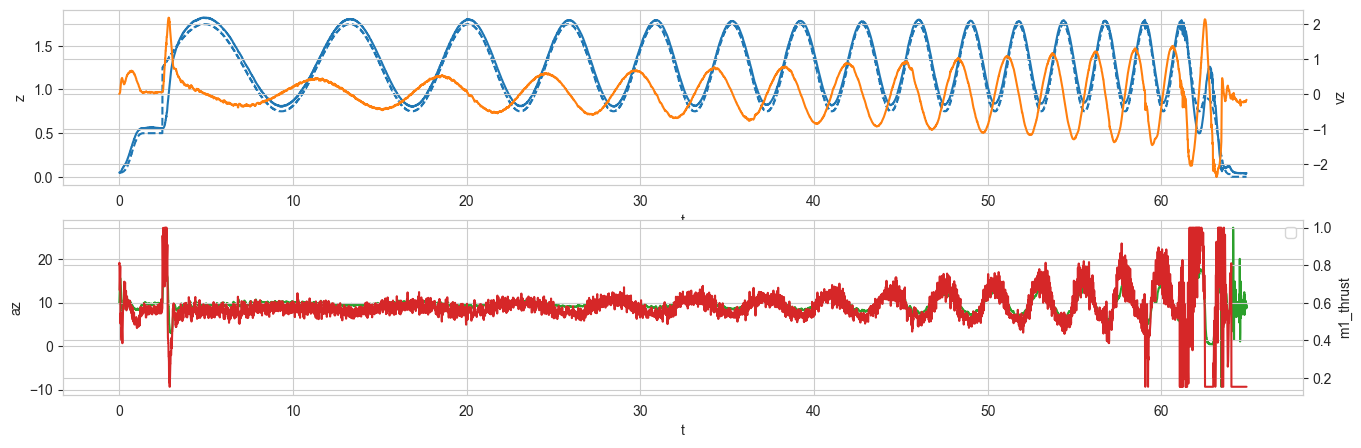

In [675]:
plt.figure(figsize=(16, 5))
plt.subplot(2, 1, 1)
sns.lineplot(merged_df, x='t', y='z', c='C0', estimator=None)
sns.lineplot(merged_df, x='t', y='z_r', c='C0', linestyle='--', estimator=None)
plt.twinx()
sns.lineplot(merged_df, x='t', y='vz', c='C1', estimator=None)
plt.subplot(2, 1, 2)
sns.lineplot(merged_df, x='t', y='az', c='C2', estimator=None)
plt.twinx()
sns.lineplot(merged_df, x='t', y='m1_thrust', c='C3', estimator=None)
plt.legend()

C:\Users\riccardo.busetto\AppData\Local\Temp\ipykernel_26916\3106358602.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


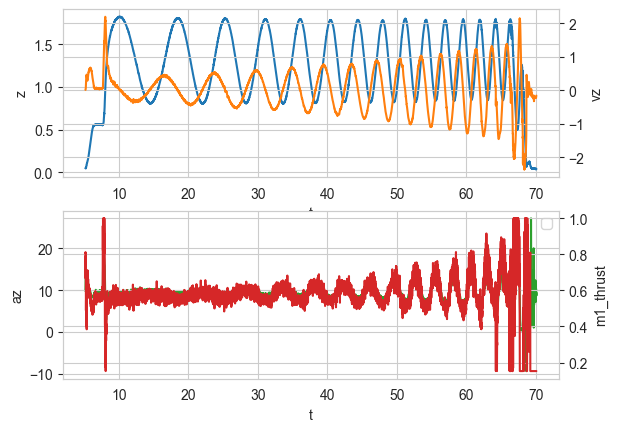

In [676]:
plt.figure()
plt.subplot(2, 1, 1)
sns.lineplot(extract_dfs['/cf/image_odom'], x='t', y='z', c='C0', estimator=None)
plt.twinx()
sns.lineplot(extract_dfs['/cf/image_odom'], x='t', y='vz', c='C1', estimator=None)
plt.subplot(2, 1, 2)
sns.lineplot(extract_dfs['/cf/image_accel'], x='t', y='az', c='C2', estimator=None)
plt.twinx()
sns.lineplot(extract_dfs['/cf/motors'], x='t', y='m1_thrust', c='C3', estimator=None)
plt.legend()

C:\Users\riccardo.busetto\AppData\Local\Temp\ipykernel_26916\3507981433.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


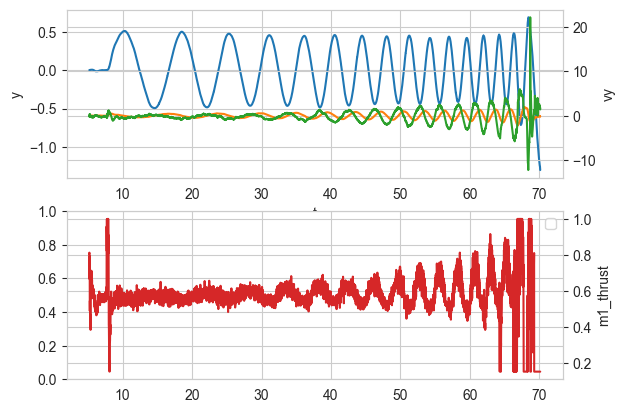

In [677]:
plt.figure()
plt.subplot(2, 1, 1)
sns.lineplot(extract_dfs['/cf/image_odom'], x='t', y='y', c='C0', estimator=None)
plt.twinx()
sns.lineplot(extract_dfs['/cf/image_odom'], x='t', y='vy', c='C1', estimator=None)
sns.lineplot(extract_dfs['/cf/image_accel'], x='t', y='ay', c='C2', estimator=None)
plt.subplot(2, 1, 2)
plt.twinx()
sns.lineplot(extract_dfs['/cf/motors'], x='t', y='m1_thrust', c='C3', estimator=None)
plt.legend()

<Axes: >

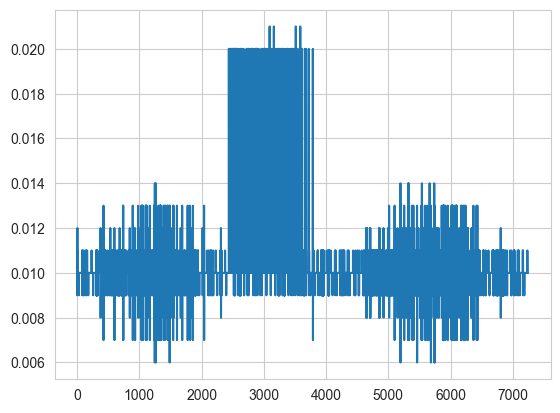

In [678]:
plt.figure()
state_wifi_df.t.diff().plot()

In [679]:
test_df = extract_dfs['/cf/image_accel']

N = len(test_df)
tmin = test_df.t.min()
tmax = test_df.t.max()
dt = test_df.t.diff().median()
tmin, tmax, dt

test_df_discard = test_df.copy()
test_df_discard['t'] = np.linspace(tmin, tmax, N)

t = np.linspace(tmin, tmax, int((tmax-tmin) // dt))

test_df_reindex = test_df \
    .drop_duplicates('t') \
    .set_index('t') \
    .reindex(t, method='nearest') \
    .reset_index()
test_df_reindex

from scipy.interpolate import interp1d


t = np.linspace(tmin, tmax, int((tmax-tmin) // dt))
test_df_lin = pd.DataFrame(index=t)
test_df_lin.index.name = 't'

for col in test_df.columns:
    # Create interpolator
    f = interp1d(test_df['t'], test_df[col], kind='linear', fill_value='extrapolate')
    test_df_lin[col] = f(t)
    

test_df_lin = test_df_lin \
    .drop(columns='t') \
    .reset_index()

test_df_lin

,t,ax,ay,az,ros_timestamp
0,5.213000,-0.029000,-0.133000,9.819190,4.570573
1,5.223003,-0.095980,-0.171020,10.384556,4.580554
2,5.233006,-0.025851,-0.240940,11.635058,4.590572
3,5.243009,0.227975,-0.137670,13.117561,4.608126
4,5.253012,0.199917,0.238151,14.677276,4.620923
...,...,...,...,...,...
6484,70.071988,2.833012,1.939086,10.354171,69.413877
6485,70.081991,2.605200,1.703207,9.178224,69.424257
6486,70.091994,2.566023,1.685011,8.661492,69.434040
6487,70.101997,2.598990,1.756979,9.502943,69.443806


<Axes: xlabel='t', ylabel='az'>

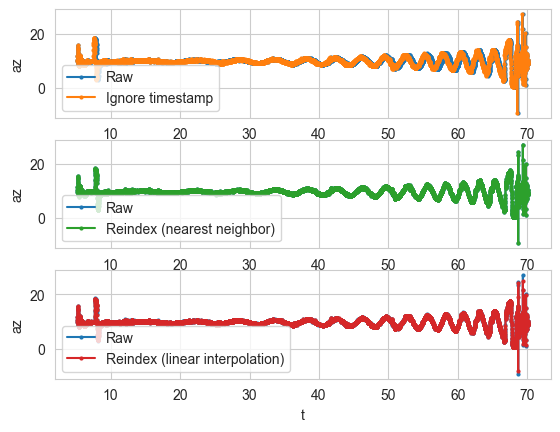

In [680]:
x = 'az'

plt.figure()
plt.subplot(3, 1, 1)
sns.lineplot(test_df, x='t', y=x, c='C0', estimator=None, label='Raw', marker='.', markeredgecolor='none')
sns.lineplot(test_df_discard, x='t', y=x, c='C1', estimator=None, label='Ignore timestamp', marker='.', markeredgecolor='none')
plt.subplot(3, 1, 2)
sns.lineplot(test_df, x='t', y=x, c='C0', estimator=None, label='Raw', marker='.', markeredgecolor='none')
sns.lineplot(test_df_reindex, x='t', y=x, c='C2', estimator=None, label='Reindex (nearest neighbor)', marker='.', markeredgecolor='none')
plt.subplot(3, 1, 3)
sns.lineplot(test_df, x='t', y=x, c='C0', estimator=None, label='Raw', marker='.', markeredgecolor='none')
sns.lineplot(test_df_lin, x='t', y=x, c='C3', estimator=None, label='Reindex (linear interpolation)', marker='.', markeredgecolor='none')

In [681]:
resampled_df.columns.tolist

<bound method IndexOpsMixin.tolist of Index(['t', 'x', 'y', 'z', 'qx', 'qy', 'qz', 'qw', 'yaw', 'pitch', 'roll',
       'vx', 'vy', 'vz', 'wx', 'wy', 'wz', 'ros_timestamp_x', 'x_mocap',
       'y_mocap', 'z_mocap', 'qx_mocap', 'qy_mocap', 'qz_mocap', 'qw_mocap',
       'yaw_mocap', 'pitch_mocap', 'roll_mocap', 'm1_thrust', 'm2_thrust',
       'm3_thrust', 'm4_thrust', 'm1_erpm', 'm2_erpm', 'm3_erpm', 'm4_erpm',
       'ros_timestamp_y', 'thrust', 'torque_roll', 'torque_pitch', 'torch_yaw',
       'ax', 'ay', 'az', 'ros_timestamp', 'x_r', 'y_r', 'z_r', 'qx_r', 'qy_r',
       'qz_r', 'qw_r', 'yaw_r', 'pitch_r', 'roll_r', 'vx_r', 'vy_r', 'vz_r',
       'wx_r', 'wy_r', 'wz_r', 'ros_timestamp_r', 'Vbat', 'can_be_armed',
       'is_armed', 'auto_arm', 'can_fly', 'is_flying', 'is_tumbled',
       'is_locked'],
      dtype='object')>